In [1]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor, ViTConfig
from PIL import Image
import numpy as np


CHECKPOINT_PATH = "Models/vit_crop/checkpoint-32110"
config = ViTConfig.from_pretrained(CHECKPOINT_PATH, output_attentions=True)

inference_model = ViTForImageClassification.from_pretrained(CHECKPOINT_PATH, config=config)
inference_processor = ViTImageProcessor.from_pretrained(CHECKPOINT_PATH)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
inference_model = inference_model.to(device)
inference_model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"Using device: {device}")

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded from Models/vit_crop/checkpoint-32110
Using device: mps


In [5]:
id_to_class = inference_model.config.id2label
class_to_id = inference_model.config.label2id
print(f"Number of classes: {len(id_to_class)}")
print(f"Classes loaded from model configuration")

Number of classes: 60
Classes loaded from model configuration


In [6]:
def predict_fn(images):
    batch_images = []
    for img in images:
        pil_img = Image.fromarray(img.astype('uint8'), 'RGB')
        batch_images.append(pil_img)
        
    inputs = inference_processor(images=batch_images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = inference_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    return probs.cpu().numpy()


In [7]:
def generate_grad_rollout(model, processor, pil_image, target_class_id):

    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    model.eval() 
    outputs = model(**inputs)
    logits = outputs.logits
    attentions = outputs.attentions 
    
    target_logit = logits[0, target_class_id]
    
    model.zero_grad()
    grads = torch.autograd.grad(target_logit, attentions, retain_graph=True, allow_unused=True)
    
    with torch.no_grad():
        num_tokens = attentions[0].shape[-1]
        rollout = torch.eye(num_tokens, device=device) 
        
        for i in range(len(attentions)):
            A_l = attentions[i] 
            G_l = grads[i]      
            
            if G_l is None:
                continue
            
            A_l = A_l.squeeze(0) 
            G_l = G_l.squeeze(0) 
            
            alpha = torch.mean(G_l, dim=(-1, -2))    
            alpha = torch.nn.functional.relu(alpha) 
            
            alpha_sum = torch.sum(alpha)
            if alpha_sum > 0:
                alpha = alpha / alpha_sum
            else:
                alpha = torch.ones_like(alpha) / alpha.shape[0]

            A_l_avg = torch.einsum('h,hsd->sd', alpha, A_l) 
            
            I = torch.eye(num_tokens, device=device)
            A_l_avg = A_l_avg + I
            
            A_l_avg = A_l_avg / A_l_avg.sum(dim=-1, keepdim=True)
            
            rollout = torch.matmul(A_l_avg, rollout)
            
    cls_attention_map = rollout[0, 1:] 
    num_patches_side = int(cls_attention_map.shape[0]**0.5)
    heatmap = cls_attention_map.reshape(num_patches_side, num_patches_side).cpu().numpy()
    
    return heatmap

In [8]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.15) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [9]:
graph = Neo4jGraph(url="neo4j://127.0.0.1:7687", username=os.getenv("NEO4J_USER"), password=os.getenv("NEO4J_PASSWORD"), enhanced_schema=True)

In [10]:
llm = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

In [125]:
ANSWER_GEN_TEMPLATE = """
### Role
You are an expert AI agricultural assistant. Your job is to provide a **precise, scientifically reliable, and user-focused** answer to the user's question about their plant.

### Information Provided
You are given the following:

1. **[Original User Question]** — This is what you must answer.
2. **[Diagnosis]** — The disease or condition detected from the image (e.g., a specific disease or "Healthy").
3. **[Retrieved Knowledge]** — A small, relevant knowledge subgraph about the diagnosis (crop → disease → symptoms → treatments).


### How to Use This Information
- Use **[Diagnosis]** to determine *what is happening* with the plant.
- Use **[Retrieved Knowledge]** to provide:
  - brief scientific justification,
  - symptom reasoning,
  - actionable recommendations,
  - or reassurance if the plant is healthy.
- You are NOT allowed to question, re-verify, or contradict the diagnosis.
- In case of contradictions between the user's question and the diagnosis, always trust the diagnosis and correct the user.

### Critical Rules (Follow Strictly)
1. **Directly answer the user's question** — this is your top priority.
2. Your answer must be:
   - **specific**,  
   - **scientifically grounded**,  
   - **clear and concise**,  
   - **actionable when needed**.
2. For "what/why/how" questions:
   - Provide a short explanation using the knowledge graph.
3. **Do NOT**:
   - Mention the knowledge graph itself.
   - Say "I cannot confirm", "I cannot verify", or anything uncertain.
   - Add unrelated information.
   - Give unsafe chemical advice.


### Output Style
- 2-4 sentences maximum.
- No lists unless absolutely necessary.
- Must sound like an agricultural expert answering a farmer.

Crop: {crop}
Diagnosis: {disease}

<context>
{context}
</context>

Question: {question}
Answer:
"""


In [126]:
from langchain_core.prompts import PromptTemplate
ANSWER_GEN_PROMPT = PromptTemplate.from_template(ANSWER_GEN_TEMPLATE)

In [127]:
answer_chain = ANSWER_GEN_PROMPT | llm

In [ ]:
CYPHER_SUBGRAPH = """
MATCH (d:Entity {name: $disease})
MATCH (c:Entity {name: $crop})
MATCH (d)-[rA:AFFECTS]->(c)

OPTIONAL MATCH (d)-[rPRESENTS:PRESENTS]->(s:Entity)
OPTIONAL MATCH (d)-[rPATHOGEN:CAUSED_BY]->(p:Entity)
OPTIONAL MATCH (d)-[rTREAT:TREATED_BY]->(t:Entity)

WITH 
     COLLECT(DISTINCT d) +
     COLLECT(DISTINCT c) +
     COLLECT(DISTINCT s) +
     COLLECT(DISTINCT p) +
     COLLECT(DISTINCT t) AS nodes,
     COLLECT(rA) + 
     COLLECT(rPRESENTS) +
     COLLECT(rPATHOGEN) + 
     COLLECT(rTREAT) AS rels

RETURN nodes, rels

"""


In [ ]:
raw = graph.query(CYPHER_SUBGRAPH, params={"disease": "Leaf Rust", "crop": "Wheat"})[0]['rels']
raw

In [66]:
def cleanup_relationships(raw):
    unique_simplified_tuples = set()
    for d1, r, d2 in raw:
        simplified_tuple = (d1['name'], r, d2['name']) 
        unique_simplified_tuples.add(simplified_tuple)

    deduplicated_list = []
    for name1, r, name2 in unique_simplified_tuples:
        original_format_tuple = ({'name': name1}, r, {'name': name2})
        deduplicated_list.append(original_format_tuple)

    return deduplicated_list

In [ ]:
cleanup_relationships(raw)

Predicted class: 'Tomato,Healthy' (ID: 44)


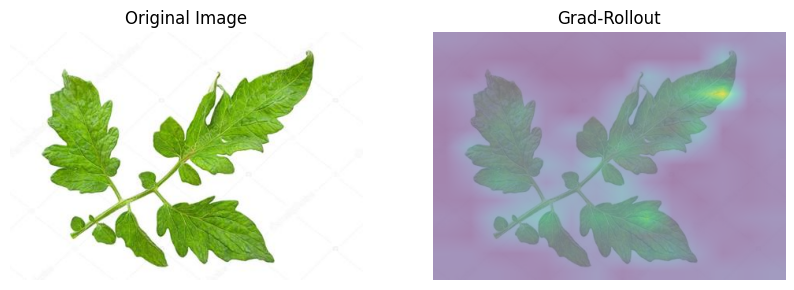

No.


In [32]:
YOUR_IMAGE_PATH_HERE = "dataset/images/Tomato,Healthy/plant_22163.jpg"
YOUR_QUERY_HERE = "Is this crop diseased?"

try:
    image_pil = Image.open(YOUR_IMAGE_PATH_HERE).convert("RGB")
    image_np = np.array(image_pil)

    probs = predict_fn([image_np])
    predicted_class_id = np.argmax(probs[0])
    predicted_class_name = id_to_class[predicted_class_id]
    print(f"Predicted class: '{predicted_class_name}' (ID: {predicted_class_id})")

    heatmap = generate_grad_rollout(
        inference_model, 
        inference_processor, 
        image_pil, 
        predicted_class_id
    )
    
    import matplotlib.pyplot as plt
    import cv2
    
    img_size = inference_processor.size['height']
    heatmap_resized = cv2.resize(heatmap, (image_pil.width, image_pil.height))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image_pil)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Grad-Rollout")
    plt.imshow(image_pil, alpha=0.5)
    plt.imshow(heatmap_resized, cmap='viridis', alpha=0.5)
    plt.axis('off')
    plt.show()

    crop, dis = predicted_class_name.split(',')
    subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })[0]['rels']
    answer = answer_chain.invoke({
        "question": YOUR_QUERY_HERE,
        "context": str(subgraph)
    })
    gen = answer.content
    print(gen)
    
except FileNotFoundError:
    print(f"Error: Image file not found at '{YOUR_IMAGE_PATH_HERE}'")
except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure your image file is a valid format (JPG, PNG, etc.)")

In [128]:
def run_pipeline(image, query):

    try:
        image_pil = Image.open(image).convert("RGB")
        image_np = np.array(image_pil)

        probs = predict_fn([image_np])
        predicted_class_id = np.argmax(probs[0])
        predicted_class_name = id_to_class[predicted_class_id]
    
        crop, dis = predicted_class_name.split(',')
        subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })[0]['rels']
        subgraph = cleanup_relationships(subgraph)
        answer = answer_chain.invoke({
            "question": query,
            "context": str(subgraph),
            "crop": crop,
            "disease": dis
        })
        return answer.content, subgraph
        
    except FileNotFoundError:
        print(f"Error: Image file not found at '{image}'")
    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your image file is a valid format (JPG, PNG, etc.)")


In [ ]:
ans, sub = run_pipeline("dataset/images/Tomato,Septoria Leaf Spot/plant_42258.jpg", "Is this spinach leaf healthy?")
ans

In [ ]:
sub

In [133]:
from langchain_core.prompts import PromptTemplate

JUDGE_PROMPT = """
You are an evaluation assistant for an agricultural Question-Answering system.

Your task is to evaluate the **overall correctness** of the system answer using a
hybrid method:

1. **Faithfulness to the Knowledge Graph (KG)**  
   - The system answer should not contradict the reference answer.
   - It should not introduce major factual errors.
   - Minor additional details are allowed **if they are scientifically accurate**.

2. **General Scientific Correctness**  
   - Even if the system adds information not in the reference, it is acceptable
     **as long as it is biologically plausible, commonly known, and helpful**.
   - Small expansions (e.g., naming pathogens, describing typical symptoms)
     should NOT be penalized if correct.

3. **Completeness & Relevance**  
   - Does the system answer provide the essential meaning of the reference?
   - Is it directly answering the user’s question?
   - Is it missing any critical facts from the reference answer?

4. **Hallucination Control**  
   - Penalize only:
     - incorrect biological claims,
     - fabricated diseases/treatments,
     - statements that contradict the reference,
     - unsafe recommendations.
   - Do NOT penalize harmless or accurate elaboration that aligns with plant pathology.

---

### Scoring Guidelines (Hybrid)

**Score 1.0 — Excellent**
- Meaning fully aligns with the reference.
- No contradictions.
- Any extra details are scientifically correct and helpful.
- No omissions of essential facts.

**Score 0.75 — Good**
- Mostly correct.
- May miss a minor detail OR include small but correct elaborations.
- No contradictions or harmful hallucinations.

**Score 0.5 — Mixed**
- Partially correct but missing important facts **OR**
  contains minor biological inaccuracies.
- Still generally aligned with the reference.

**Score 0.25 — Poor**
- Major omissions OR multiple incorrect facts.
- Contradicts important parts of the reference.

**Score 0.0 — Incorrect/Harmful**
- Contradicts the reference answer.
- Contains biologically incorrect statements or unsafe recommendations.
- Introduces fake diseases or false facts.

---

### Output Format (JSON only)

{{
  "score": float (0 to 1),
  "explanation": "Brief explanation of correctness and issues"
}}

---

QUESTION: {question}
REFERENCE_ANSWER: {reference}
SYSTEM_ANSWER: {system_answer}
"""

JUDGE_PROMPT_TEMPLATE = PromptTemplate.from_template(JUDGE_PROMPT)

In [ ]:
gen

In [ ]:
def evaluate_answer(question, generated_answer, subgraph):
    judge_chain = JUDGE_PROMPT_TEMPLATE | llm
    inputs = {
        "question": question,
        "system_answer": generated_answer,
        "reference": subgraph,
    }
    
    evaluation = judge_chain.invoke(inputs)
    return evaluation

In [ ]:
evaluate_answer(
    question="What are the effective control measures that can be implemented to manage Tomato Leaf Mold?",
    subgraph=subgraph,
    generated_answer=gen
).content

In [135]:
import re

def extract_json(text):
    pattern = r"\{[\s\S]*?\}"
    match = re.search(pattern, text)
    if not match:
        raise ValueError("No JSON object found in the text.")

    json_str = match.group(0)

    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        raise ValueError("Found JSON-like content but failed to parse.")

In [ ]:
import json
import csv
from tqdm import tqdm

def run_full_test(
    test_json_path,
    output_csv_path,
):

    with open(test_json_path, "r") as f:
        dataset = json.load(f)

    with open(output_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "question_id",
                "image",
                "question",
                "system_answer",
                "judge_score",
                "explanations",
            ]
        )
        writer.writeheader()

    for item in tqdm(dataset, desc="Running tests"):
        q_id = item.get("question_id")
        image = item.get("image")

        if image.startswith("/"):
            image = image[1:]

        question = item.get("question")

        try:
            system_answer, subgraph = run_pipeline(image, question)
        except Exception as e:
            system_answer = f"PIPELINE ERROR: {str(e)}"
            subgraph = ""

        try:
            eval1_text = evaluate_answer(question, system_answer, subgraph).content
            judge_score = extract_json(eval1_text).get('score')
            explainations = extract_json(eval1_text).get('explanation')

            print(f"Evaluated QID {q_id}: score = {judge_score}")

        except Exception as e:
            print(e)
            break

        # Append single row
        with open(output_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=[
                "question_id",
                "image",
                "question",
                "system_answer",
                "judge_score",
                "explanations",
            ])
            writer.writerow({
                "question_id": q_id,
                "image": image,
                "question": question,
                "system_answer": system_answer,
                "judge_score": judge_score,
                "explanations": explainations,
            })

    print(f"Saved results to {output_csv_path}")


In [ ]:
run_full_test(
    test_json_path="dataset/test_dataset/disease_diagnosis.json",
    output_csv_path="Results/test_2.csv",
)

In [145]:
import csv

def compute_avg_score(csv_path):
    scores = []

    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                score = float(row["judge_score"])
                scores.append(score)
            except:
                pass  

    if len(scores) == 0:
        raise ValueError("No judge_score values found.")

    avg_score = sum(scores) / len(scores)

    return avg_score

In [152]:
avg = compute_avg_score("Results/test_2.csv")
print("Average Score (0-1):", avg)

Average Score (0-1): 0.9083333333333333
